In [1]:
import os 
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

import pandas as pd 
import numpy as np
from sklearn import tree
import graphviz
from src.model_utils import load_model, train_model, save_model, tune_model
from src.preprocessor_utils import convert_time_to_hour
from src.eval_metric import f1_benchmark, AUPRC, evaluate_model
from src.plot import plot_confusion_matrix_percent,plot_prediction_distribution, find_optimal_threshold
import joblib

d:\anaconda\envs\tf_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_path = os.path.join(project_root,"data","train_goc.csv")
df = pd.read_csv(data_path)
test_path = os.path.join(project_root,"data",'test_goc.csv')
df_test = pd.read_csv(test_path)

x_t = df_test.drop('Class',axis = 1)
y_test = df_test['Class']

x = df.drop('Class', axis = 1)
y_train = df['Class']

preprocessor_path = os.path.join(project_root,"data","creditcard_preprocessor.pkl")
preprocessor = joblib.load(preprocessor_path)

x_train = preprocessor.transform(x)
x_test = preprocessor.transform(x_t)

ta sẽ chạy thử mô hình với cấu hình tham số mặc định

In [5]:
rf_default = train_model(x_train,y_train,"rf")

Cảnh báo không tình thấy file: configs/rf_config.json. sử dụng tham số mặc định
Training RF...
Train successful!!


--- ĐÁNH GIÁ: RANDOMFOREST ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.90      0.76      0.82        95

    accuracy                           1.00     56746
   macro avg       0.95      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.9295
PR-AUC (AUPRC): 0.7896 (Quan trọng cho Fraud)


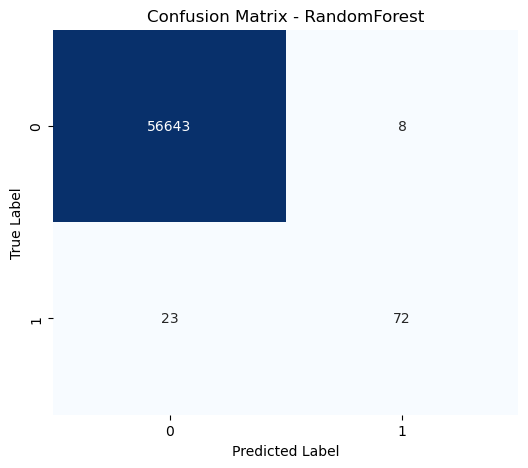

In [6]:
evaluate_model(rf_default,x_test,y_test,"RandomForest")

đây là môt bước đột phá so với mô hình cây quyết định khi điểm số tăng lên một cách đáng kể khi chưa điều chình tham số phù hợp với điêm nổi bật như:
+ recall = 0.90 rất cao 
+ PR-AUC = 0.78 cao hơn hẳng so với mô hình đã hiểu chỉnh siêu tham số ở cây quyết định là 0.71

ta sẽ hiểu chỉnh siêu tham số bằng RandomizedSearchcv

In [7]:
rcv_config = os.path.join(project_root,"configs","rf_rcv_over.json")

In [8]:
tune_rcv_rv = tune_model(x_train,y_train,"rf","rcv",rcv_config)

--- Bắt đầu Tuning RF bằng RCV ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits

=== Kết quả Tuning ===
Best Params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 20, 'criterion': 'entropy'}
Best Score (f1): 0.8478


--- ĐÁNH GIÁ: RANDOMIZEDSEARCHCV ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.89      0.75      0.81        95

    accuracy                           1.00     56746
   macro avg       0.94      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.9398
PR-AUC (AUPRC): 0.8166 (Quan trọng cho Fraud)


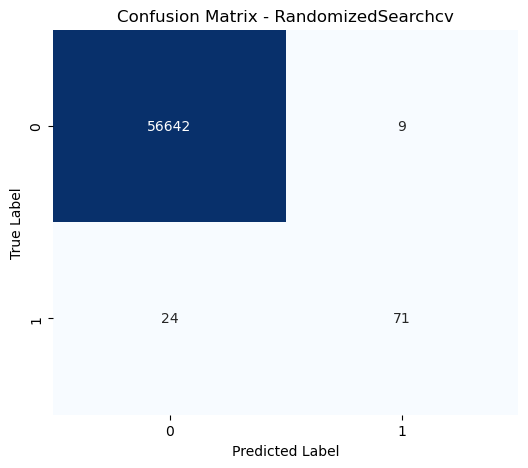

In [9]:
evaluate_model(tune_rcv_rv[0],x_test,y_test,"RandomizedSearchcv")

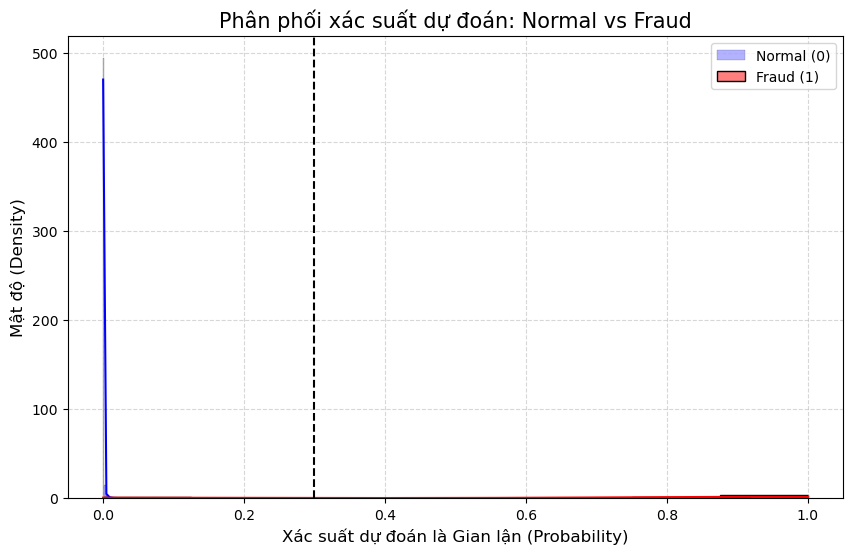

In [10]:
plot_prediction_distribution(tune_rcv_rv[0],x_test,y_test)

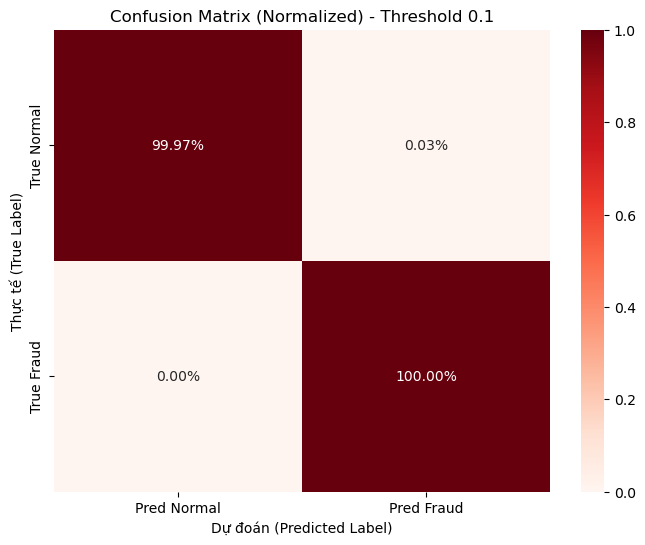

In [23]:
plot_confusion_matrix_percent(tune_rcv_rv[0],x_train,y_train,threshold=0.1)

--- KẾT QUẢ TỐI ƯU (Beta=2) ---
Ngưỡng cắt tốt nhất (Best Threshold): 0.0987
Tại ngưỡng này đạt F2-Score: 0.8034
 -> Precision: 0.8172
 -> Recall:    0.8000


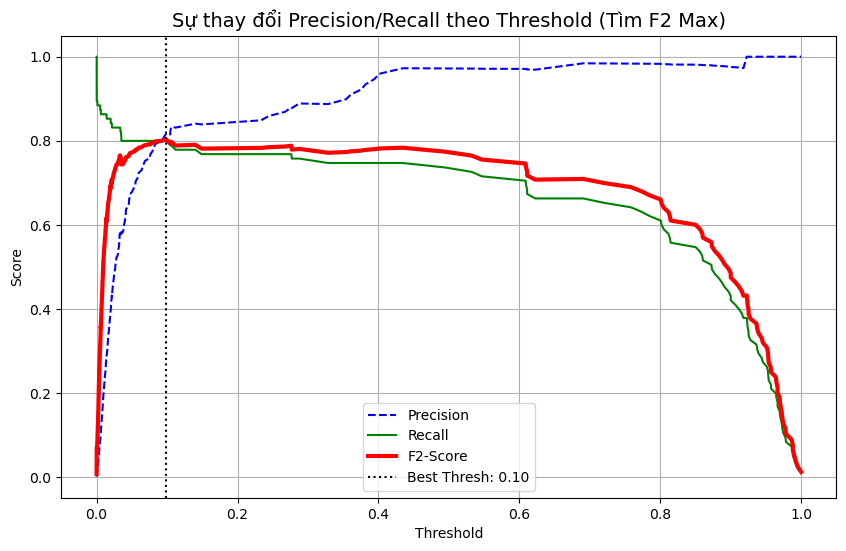

In [ ]:
# tìm điểm thershold tốt nhất: 
best_threshodld= find_optimal_threshold(tune_rcv_rv[0],x_test,y_test,beta = 2)


In [14]:
print(best_threshodld)

0.098705704018204


giá trị này dùng để bắt gian lận như với 0.5 là 50% thì sẽ bị bắt nếu dưới thì đc thả nhưng thực tế thì với xác suất 49% phần trăm vẫn khá cao và rủi ro cho ngân hàng nên cần tìm điểm bắt tốt nhất.

In [21]:
rf_opt_path = os.path.join(project_root,"configs","rf_optuna_raw.json")

In [22]:
tune_gcv_rf = tune_model(x_train,y_train,"rf","optuna",rf_opt_path,cv = 3)

d:\PYTHON\data_mining\fraud-detecion-project\src\model_utils.py:162: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  return OptunaSearchCV(
[I 2025-12-09 03:00:02,457] A new study created in memory with name: no-name-d476df87-7829-42e9-9ee6-947e9a388ffd


--- Bắt đầu Tuning RF bằng OPTUNA ---


[I 2025-12-09 03:06:41,702] Trial 9 finished with value: 0.8364000648077786 and parameters: {'n_estimators': 150, 'max_depth': 48, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 9 with value: 0.8364000648077786.
[I 2025-12-09 03:08:40,011] Trial 6 finished with value: 0.8249082985925091 and parameters: {'n_estimators': 200, 'max_depth': 34, 'min_samples_split': 18, 'min_samples_leaf': 10, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 9 with value: 0.8364000648077786.
[I 2025-12-09 03:09:12,319] Trial 2 finished with value: 0.8397216412972778 and parameters: {'n_estimators': 150, 'max_depth': 45, 'min_samples_split': 18, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 2 with value: 0.8397216412972778.
[I 2025-12-09 03:13:58,123] Trial 8 finished with value: 0.8126407428759551 and parameters: {'n_estimators': 250, 'max_depth': 40, 'min_samples_split': 11, 'min_samples_leaf'


=== Kết quả Tuning ===
Best Params: {'n_estimators': 250, 'max_depth': 23, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'gini'}
Best Score (f1): 0.8502


--- ĐÁNH GIÁ: OPTUNA_RANDOMFOREST ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.90      0.76      0.82        95

    accuracy                           1.00     56746
   macro avg       0.95      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.9689
PR-AUC (AUPRC): 0.7997 (Quan trọng cho Fraud)


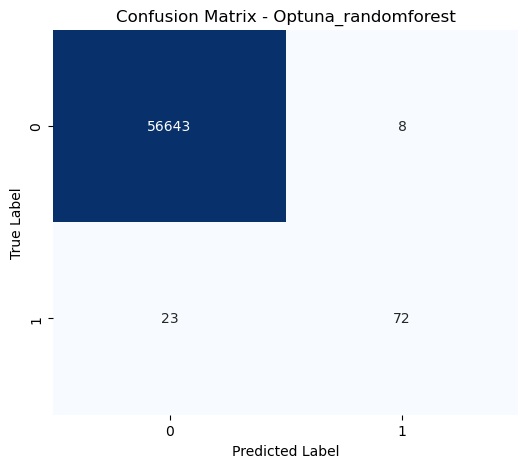

In [25]:
evaluate_model(tune_gcv_rf[0],x_test,y_test,"Optuna_randomforest")

In [3]:
optuna_path = os.path.join(project_root,"models","model_optuna_rf_raw.pkl")
model_optuna = joblib.load(optuna_path)
rcv_rf_path = os.path.join(project_root,"models","model_rcv_rf_raw.pkl")
model_rcv = joblib.load(rcv_rf_path)

--- KẾT QUẢ TỐI ƯU (Beta=2) ---
Ngưỡng cắt tốt nhất (Best Threshold): 0.1400
Tại ngưỡng này đạt F2-Score: 0.7906
 -> Precision: 0.8409
 -> Recall:    0.7789


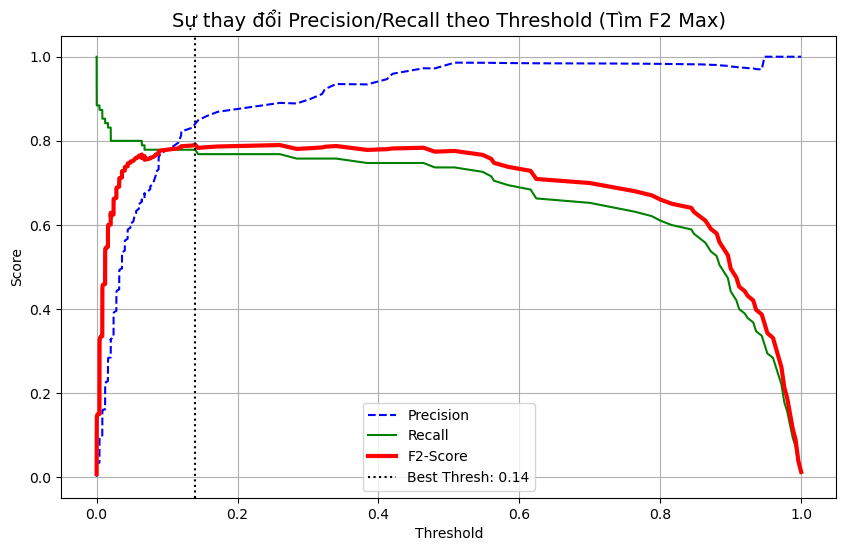

In [4]:
thershold_optuna = find_optimal_threshold(model_optuna,x_test,y_test,beta=2)

--- KẾT QUẢ TỐI ƯU (Beta=2) ---
Ngưỡng cắt tốt nhất (Best Threshold): 0.0987
Tại ngưỡng này đạt F2-Score: 0.8034
 -> Precision: 0.8172
 -> Recall:    0.8000


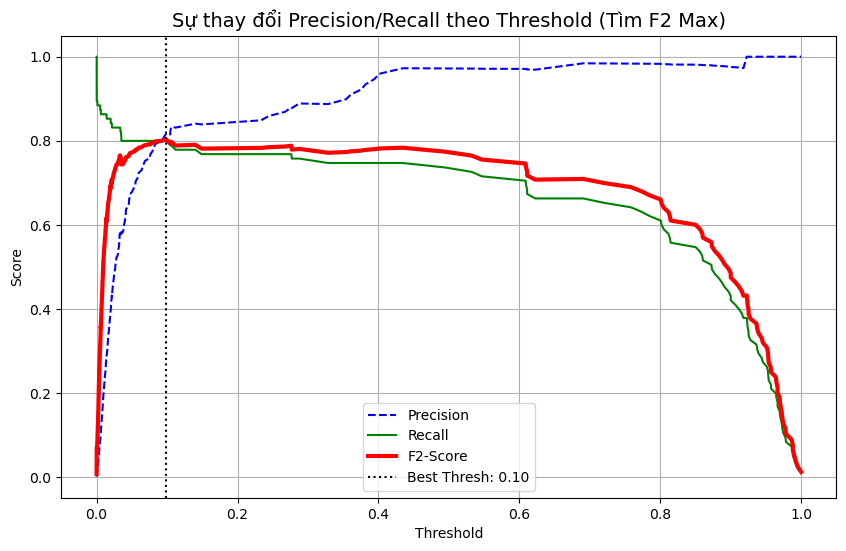

In [5]:
thershold_rcv = find_optimal_threshold(model_rcv,x_test,y_test,beta=2)

--- ĐÁNH GIÁ: MODEL ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.84      0.78      0.81        95

    accuracy                           1.00     56746
   macro avg       0.92      0.89      0.90     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.9689
PR-AUC (AUPRC): 0.7997 (Quan trọng cho Fraud)


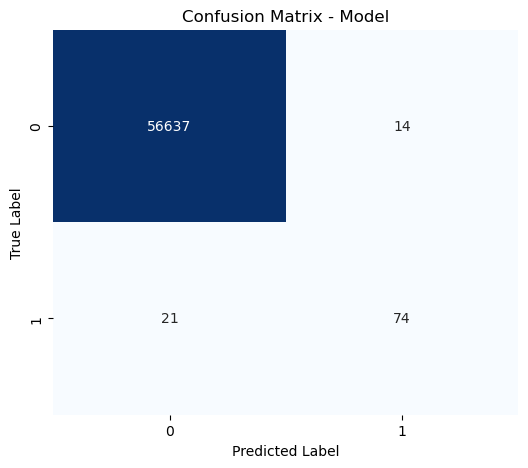

In [6]:
evaluate_model(model_optuna,x_test,y_test,thershold=thershold_optuna)

--- ĐÁNH GIÁ: MODEL ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.82      0.80      0.81        95

    accuracy                           1.00     56746
   macro avg       0.91      0.90      0.90     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.9398
PR-AUC (AUPRC): 0.8166 (Quan trọng cho Fraud)


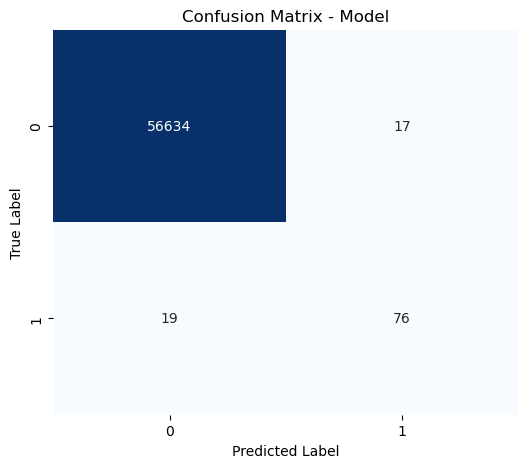

In [9]:
evaluate_model(model_rcv,x_test,y_test,thershold=thershold_rcv)

ta sẽ chọn của randomizedSearchCV